# Image Processing & Object Segmentation using FFT and Watershed
This project implements an advanced digital image processing pipeline to count objects from an image degraded by periodic noise.

**Main Pipeline:**
1. **Preprocessing:** Convert image to grayscale and resize.
2. **Frequency Domain Noise Reduction (FFT):** Apply Fast Fourier Transform and a Notch Filter to remove sinusoidal noise.
3. **Image Enhancement:** Apply morphological operations (Top-hat), normalize brightness, and smooth the image.
4. **Binarization:** Use Adaptive Thresholding to separate objects from the background.
5. **Object Segmentation & Counting (Watershed):** Identify precise boundaries and accurately count the total number of objects.

In [1]:
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configure global Matplotlib display settings
plt.rcParams['figure.figsize'] = (10, 8)

def show_image(image, title="Image", figsize=(8, 6)):
    """
    Cross-platform image display utility using Matplotlib.
    Automatically handles both RGB (color) and Grayscale images.
    """
    plt.figure(figsize=figsize)
    if len(image.shape) == 3:
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

## 1. Load Image & Periodic Noise Reduction (FFT & Notch Filter)

In [2]:
import os
import urllib.request
import cv2
import numpy as np

# 1. Define the directory for images
image_dir = 'images'

# 2. Automatically download a sample image if it doesn't exist
# (It ensures the Notebook runs smoothly even if the user hasn't downloaded the repo)
sample_filename = 'image_1.png'
sample_path = os.path.join(image_dir, sample_filename)

if not os.path.exists(sample_path):
    print(f"Sample image not found at '{sample_path}'. Attempting to download...")
    os.makedirs(image_dir, exist_ok=True)

    # Replace this URL with the raw link to image on Github
    sample_url = 'https://raw.githubusercontent.com/kietnguyen-0902/Image-Segmentation-FFT-Watershed/refs/heads/main/images/image_1.png'

    try:
        urllib.request.urlretrieve(sample_url, sample_path)
        print("Download successful!")
    except Exception as e:
        print(f"Failed to download image. Error: {e}")
        print("Please upload the image manually or check the URL.")

# 3. List all available images in the directory for easy reference
if os.path.exists(image_dir):
    # Filter only image files to avoid clutter
    available_images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Available images in '{image_dir}': {available_images}")

Available images in 'images': ['image_4.png', 'image_2.png', 'image_3.png', 'image_1.png']


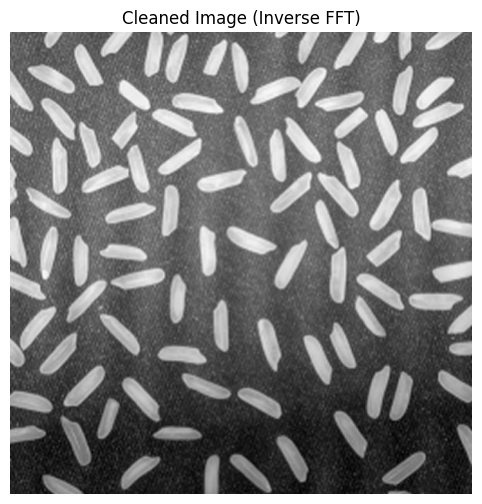

In [3]:
# 1. SELECT THE IMAGE TO PROCESS
# Change this variable to test with other images in the folder
selected_filename = 'image_1.png'
# =====================================================================

image_path = os.path.join(image_dir, selected_filename)

# 2. Load image and validate
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}. Execution stopped.")

# 3. Resize image maintaining aspect ratio
h, w = image.shape[:2]
target_width = 461
aspect_ratio = target_width / float(w)
target_height = int(h * aspect_ratio)

resized_image = cv2.resize(image, (target_width, target_height), interpolation=cv2.INTER_AREA)
output_image = image.copy() # Store a copy of original image if needed later

# 4. 2D Fast Fourier Transform (FFT)
f_transform = np.fft.fft2(resized_image)
f_shift = np.fft.fftshift(f_transform)
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

# 5. Generate Notch Filter mask to block periodic noise
rows, cols = resized_image.shape
center_row, center_col = rows // 2, cols // 2
mask = np.ones((rows, cols), np.uint8)

# Define relative coordinates of noise peaks in the frequency spectrum
noise_offsets = [
    (0, 9),
]
filter_radius = 1

for dy, dx in noise_offsets:
    cv2.circle(mask, (center_col + dx, center_row + dy), filter_radius, 0, -1)
    cv2.circle(mask, (center_col - dx, center_row - dy), filter_radius, 0, -1)

f_shift_filtered = f_shift * mask

# 6. Inverse FFT to restore the image to spatial domain
f_ishift = np.fft.ifftshift(f_shift_filtered)
restored_img = np.fft.ifft2(f_ishift)
restored_img = np.abs(restored_img)
restored_img = np.clip(restored_img, 0, 255).astype(np.uint8)

show_image(restored_img, title="Cleaned Image (Inverse FFT)")

## 2. Image Enhancement & Binarization


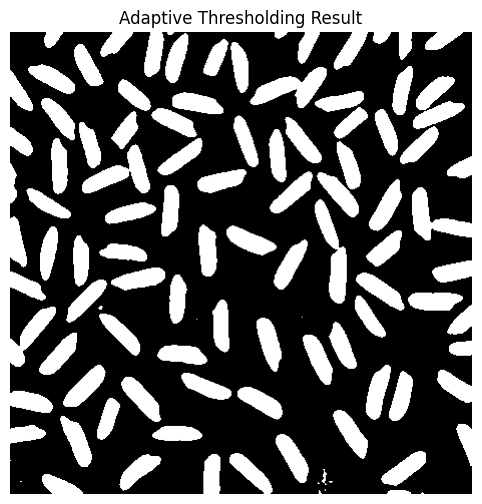

In [4]:
# 1. Correct uneven illumination using Morphological Top-hat
tophat_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
tophat_img = cv2.morphologyEx(restored_img, cv2.MORPH_TOPHAT, tophat_kernel)

# 2. Brightness Normalization (Contrast Stretching)
normalized_img = cv2.normalize(tophat_img, None, 0, 255, cv2.NORM_MINMAX)
normalized_8u = np.uint8(normalized_img)

# 3. Noise reduction using spatial filtering
median_filtered = cv2.medianBlur(normalized_8u, 3)
gaussian_filtered = cv2.GaussianBlur(median_filtered, (3, 3), 0)

# 4. Binarization using Adaptive Thresholding
binary_thresh = cv2.adaptiveThreshold(
    gaussian_filtered,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    401,
    -2
)

show_image(binary_thresh, title="Adaptive Thresholding Result")

## 3. Morphological Operations

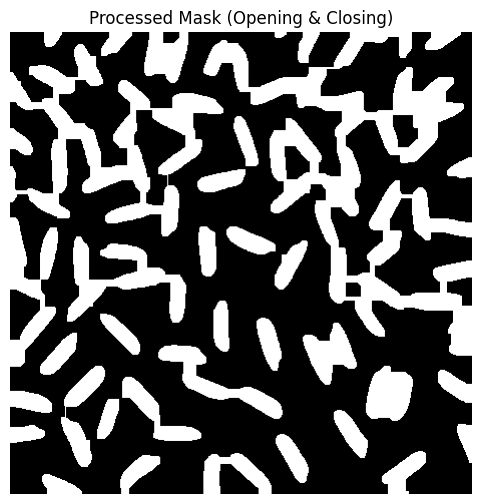

In [5]:
# Define rectangular kernel for structural cleaning
morph_kernel = np.ones((3, 3), np.uint8)

# Apply Morphological Opening to remove small background noise
opening = cv2.morphologyEx(binary_thresh, cv2.MORPH_OPEN, morph_kernel, iterations=2)

# Apply Morphological Closing to fill small holes inside objects
processed_mask = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, morph_kernel, iterations=5)

show_image(processed_mask, title="Processed Mask (Opening & Closing)")

## 4. Object Segmentation and Counting (Watershed)

Total objects detected (excluding background): 99


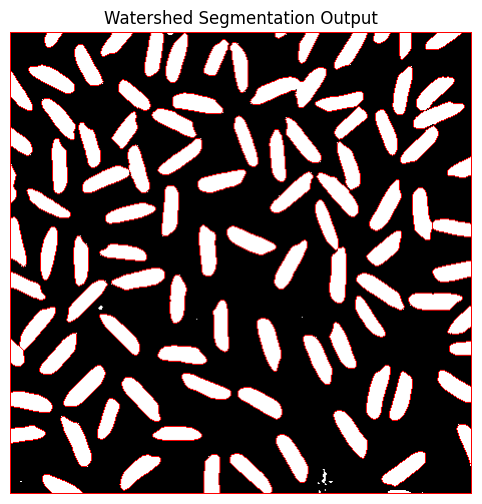

In [6]:
# Input mask for Watershed segmentation
binary_input = binary_thresh # Using the raw threshold map as per original logic

# 1. Identify sure background area
kernel_3x3 = np.ones((3, 3), np.uint8)
sure_bg = cv2.dilate(binary_input, kernel_3x3, iterations=2)

# 2. Identify sure foreground area using Distance Transform
dist_transform = cv2.distanceTransform(binary_input, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.3 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 3. Identify unknown regions (object boundaries)
unknown_regions = cv2.subtract(sure_bg, sure_fg)

# 4. Marker labelling for Watershed initialization
num_labels, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1 # Background should be labeled 1, not 0
markers[unknown_regions == 255] = 0 # Mark unknown boundaries with 0

# 5. Apply Watershed Algorithm
watershed_result = cv2.cvtColor(binary_input, cv2.COLOR_GRAY2BGR)
cv2.watershed(watershed_result, markers)

# 6. Highlight boundaries in red
watershed_result[markers == -1] = [0, 0, 255]

# Calculate and display final count
total_objects = num_labels - 1
print(f"Total objects detected (excluding background): {total_objects}")
show_image(watershed_result, title="Watershed Segmentation Output")